In [1]:
# =========================
# Basic Libraries
# =========================
import os
import cv2
import numpy as np

# =========================
# TensorFlow / Keras
# =========================
from tensorflow.keras.models import load_model

# =========================
# Optional (for displaying image)
# =========================
import matplotlib.pyplot as plt

In [2]:
from tensorflow.keras.models import load_model

binary_models = [
    load_model(f"binary_model_fold_{i}.h5") for i in range(1, 6)
]

multi_models = [
    load_model(f"multi_model_fold_{i}.h5") for i in range(1, 6)
]

In [3]:
import cv2
import numpy as np

def predict_ensemble(image_path):
    img = cv2.imread(image_path)

    if img is None:
        print("❌ Image not found")
        return

    img = cv2.resize(img, (128,128))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    # -------- Stage 1: Binary Ensemble --------
    preds_bin = [model.predict(img)[0][0] for model in binary_models]
    avg_bin = np.mean(preds_bin)

    if avg_bin < 0.5:
        print("✅ GOOD ROAD (No pothole)")
        return

    print("⚠️ Pothole Detected!")

    # -------- Stage 2: Multi Ensemble --------
    preds_multi = [model.predict(img) for model in multi_models]

    avg_multi = np.mean(preds_multi, axis=0)
    class_index = np.argmax(avg_multi)

    labels = ["Satisfactory", "Poor", "Very Poor"]

    print("🚧 Severity:", labels[class_index])

In [6]:
predict_ensemble("../test.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
✅ GOOD ROAD (No pothole)


In [7]:
predict_ensemble("../test2.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
⚠️ Pothole Detected!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
🚧 Severity: Very Poor


In [8]:
predict_ensemble("../test1.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
⚠️ Pothole Detected!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
🚧 Severity: Very Poor


In [9]:
predict_ensemble("../test3.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
⚠️ Pothole Detected!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
🚧 Severity: Poor


In [10]:
predict_ensemble("../test4.jpeg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
⚠️ Pothole Detected!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
🚧 Severity: Poor


In [11]:
# =========================
# Imports
# =========================
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import os

# =========================
# Load Models (Ensemble)
# =========================
binary_models = [
    load_model(f"binary_model_fold_{i}.h5") for i in range(1, 6)
]

multi_models = [
    load_model(f"multi_model_fold_{i}.h5") for i in range(1, 6)
]

# =========================
# Labels
# =========================
multi_labels = ["Satisfactory", "Poor", "Very Poor"]

# =========================
# Prediction Function
# =========================
def predict_and_show(image_path):
    image_path = os.path.abspath(image_path)

    if not os.path.exists(image_path):
        print("❌ Image not found:", image_path)
        return

    img = cv2.imread(image_path)

    if img is None:
        print("❌ Cannot read image")
        return

    # Preprocess
    img_resized = cv2.resize(img, (128, 128))
    img_norm = img_resized / 255.0
    img_input = np.expand_dims(img_norm, axis=0)

    # =========================
    # Stage 1: Binary Ensemble
    # =========================
    preds_bin = [model.predict(img_input)[0][0] for model in binary_models]
    avg_bin = np.mean(preds_bin)

    if avg_bin < 0.5:
        label = "Good Road (No Pothole)"
        confidence = (1 - avg_bin) * 100

    else:
        # =========================
        # Stage 2: Multi Ensemble
        # =========================
        preds_multi = [model.predict(img_input) for model in multi_models]
        avg_multi = np.mean(preds_multi, axis=0)

        class_index = np.argmax(avg_multi)
        confidence = avg_multi[0][class_index] * 100

        label = f"Pothole Detected → {multi_labels[class_index]}"

    # =========================
    # Show Image
    # =========================
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6,6))
    plt.imshow(img_rgb)
    plt.title(f"{label}\nConfidence: {confidence:.2f}%")
    plt.axis("off")
    plt.show()

    print("Prediction:", label)
    print("Confidence:", f"{confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


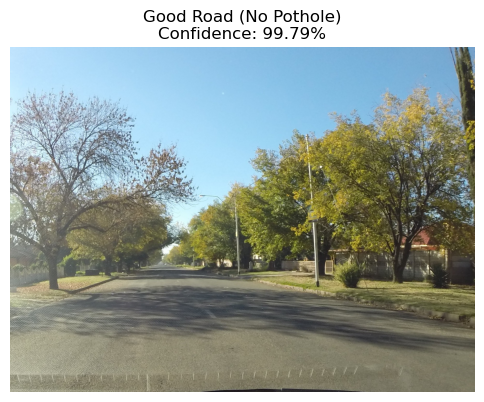

Prediction: Good Road (No Pothole)
Confidence: 99.79%


In [12]:
predict_and_show("../test.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


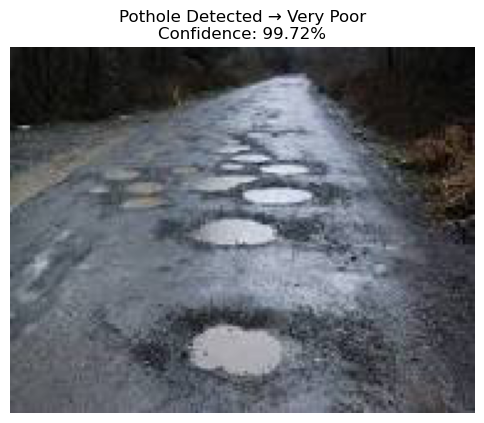

Prediction: Pothole Detected → Very Poor
Confidence: 99.72%


In [13]:
predict_and_show("../test1.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


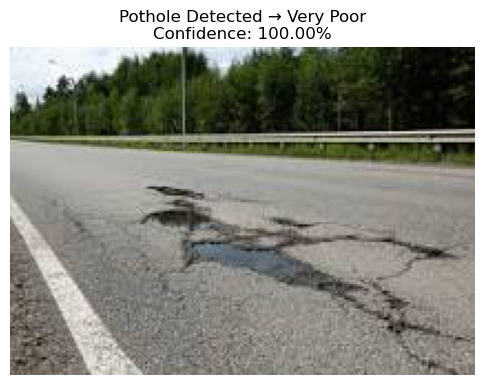

Prediction: Pothole Detected → Very Poor
Confidence: 100.00%


In [14]:
predict_and_show("../test2.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


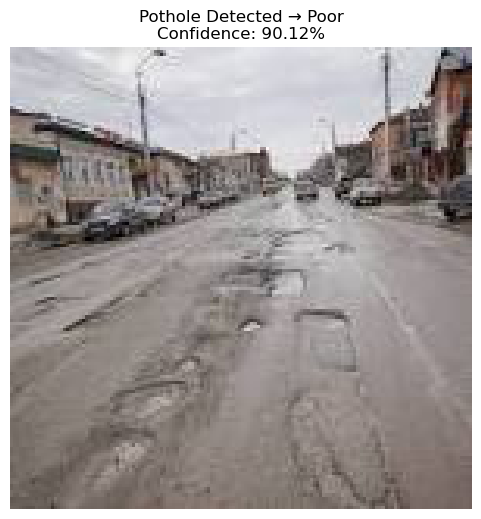

Prediction: Pothole Detected → Poor
Confidence: 90.12%


In [ ]:
predict_and_show("../test3.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


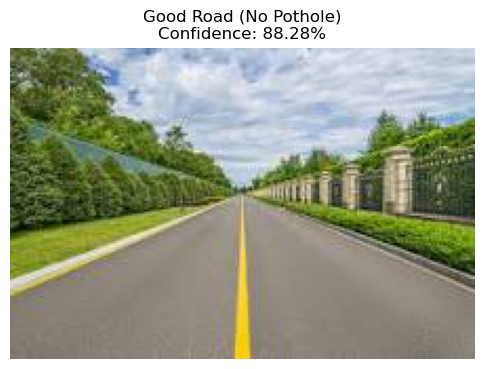

Prediction: Good Road (No Pothole)
Confidence: 88.28%


In [17]:
predict_and_show("../test5.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


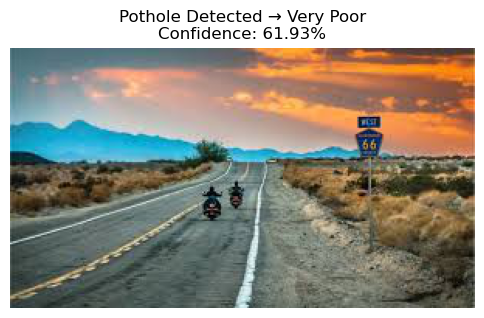

Prediction: Pothole Detected → Very Poor
Confidence: 61.93%


In [19]:
predict_and_show("../test7.jpg")